In [20]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from jax import lax
from numpyro.contrib.control_flow import scan
from numpyro.infer import MCMC, NUTS

class CGSLOU:
    def __init__(self, K, D, target_accept_prob=0.95):
        self.K = K  # Latent factors
        self.D = D  # Observed dimensions
        self.target_accept_prob = target_accept_prob
        self.mcmc = None
        
    def model(self, Nsub, N_total, start_idx, end_idx, t, y, s_cov):
        L_cov = s_cov.shape[1]
        
        # --- 1. Structured Theta (S + K) ---
        # B_raw forms the Symmetric Positive Definite part S
        B_raw = numpyro.sample("B_raw", dist.Normal(0, 0.5).expand([self.K, self.K]))
        epsilon = 1e-3
        S = jnp.matmul(B_raw, B_raw.T) + epsilon * jnp.eye(self.K)
        
        # M_raw forms the Skew-Symmetric part K
        M = numpyro.sample("M_raw", dist.Normal(0, 0.5).expand([self.K, self.K]))
        K_mat = M - M.T
        
        # Theta = S + K guarantees Re(eigenvalues) > 0
        theta = numpyro.deterministic("theta_matrix", S + K_mat)
        
        # --- 2. Mean & Volatility ---
        alpha = numpyro.sample("alpha", dist.Normal(0, 2).expand([self.K]))
        phi_latent = numpyro.sample("phi_latent", dist.Normal(0, 2).expand([self.K, L_cov]))
        
        gamma_sd = numpyro.sample("gamma_sd", dist.HalfNormal(1.0).expand([self.K]))
        gamma_L_corr = numpyro.sample("gamma_L_corr", dist.LKJCholesky(self.K, concentration=1.0))
        L_vol = jnp.diag(gamma_sd) @ gamma_L_corr 
        
        # --- 3. Observation & Sparsity ---
        psi_diag = numpyro.sample("psi_diag", dist.HalfNormal(0.5).expand([self.D]))
        tau = numpyro.sample("tau", dist.HalfNormal(1.0))
        lamb_local = numpyro.sample("lamb_local", dist.HalfNormal(1.0).expand([self.D, self.K]))
        Lambda = numpyro.sample("Lambda", dist.Normal(0, tau * lamb_local))
        Lambda = jnp.where(jnp.triu(jnp.ones((self.D, self.K)), k=1), 0.0, Lambda)

        # --- 4. Latent Scan ---
        steps_per_sub = N_total // Nsub
        slopes = jnp.matmul(s_cov, phi_latent.T)
        
        x_all = []
        for i in range(Nsub):
            with numpyro.handlers.scope(prefix=f"sub_{i}"):
                s_i = start_idx[i]
                subject_t = lax.dynamic_slice(t, (s_i,), (steps_per_sub,))
                
                mu_0 = alpha + slopes[i] * subject_t[0]
                x0 = numpyro.sample("x_init", dist.Normal(mu_0, 1.0))
                
                def transition_fn(carry, inputs):
                    x_prev = carry
                    t_p, t_c = inputs
                    dt = t_c - t_p
                    mu_p = alpha + slopes[i] * t_p
                    mu_c = alpha + slopes[i] * t_c
                    
                    drift_mat = jax.scipy.linalg.expm(-theta * dt)
                    mu_xt = mu_c + jnp.matmul(drift_mat, (x_prev - mu_p))
                    xt = numpyro.sample("xt", dist.MultivariateNormal(loc=mu_xt, scale_tril=L_vol * jnp.sqrt(dt)))
                    return xt, xt

                _, x_path = scan(transition_fn, x0, (subject_t[:-1], subject_t[1:]))
                x_all.append(jnp.concatenate([x0[None, :], x_path], axis=0))

        x_flat = jnp.concatenate(x_all, axis=0)
        numpyro.deterministic("x_trace", x_flat)
        
        mu_obs = jnp.matmul(x_flat, Lambda.T)
        with numpyro.plate("data", N_total):
            numpyro.sample("y", dist.Normal(mu_obs, psi_diag).to_event(1), obs=y)

    # --- THE MISSING FIT METHOD ---
    def fit(self, rng_key, num_samples=500, num_warmup=500, num_chains=1, **kwargs):
        """
        Initializes the NUTS kernel and runs the MCMC sampler.
        """
        kernel = NUTS(self.model, target_accept_prob=self.target_accept_prob)
        self.mcmc = MCMC(
            kernel, 
            num_warmup=num_warmup, 
            num_samples=num_samples, 
            num_chains=num_chains,
            progress_bar=True
        )
        self.mcmc.run(rng_key, **kwargs)
        return self.mcmc.get_samples()

In [21]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from jax import lax
from numpyro.contrib.control_flow import scan

def generate_structured_mou_data(Nsub=10, K=2, D=10, L=3, steps=30):
    key = jax.random.PRNGKey(42)
    k1, k2, k3, k4, k5, k6 = jax.random.split(key, 6)
    
    N_total = Nsub * steps
    t_single = jnp.linspace(0, 5, steps)
    t = jnp.tile(t_single, Nsub)
    s_cov = jax.random.normal(k1, (Nsub, L))
    start_idx = jnp.arange(0, N_total, steps)
    
    # --- 1. Generate True Structured Theta (S + K) ---
    # Symmetric part S (SPD)
    B_true = jax.random.normal(k2, (K, K)) * 0.5
    S_true = B_true @ B_true.T + 0.01 * jnp.eye(K)
    # Skew-symmetric part K
    M_true = jax.random.normal(k3, (K, K)) * 0.5
    K_true = M_true - M_true.T
    theta_true = S_true + K_true # Reversion matrix
    
    # --- 2. Other Parameters ---
    alpha_true = jnp.array([0.5, -0.5])
    phi_true = jax.random.normal(k4, (K, L))
    L_vol_true = jnp.array([[0.4, 0.0], [0.2, 0.3]]) # Cholesky Volatility
    
    Lambda_true = jnp.zeros((D, K))
    Lambda_true = Lambda_true.at[0, 0].set(1.0)
    Lambda_true = Lambda_true.at[1, 1].set(-1.0)
    Lambda_true = Lambda_true.at[2:, :].set(jax.random.normal(k5, (D-2, K)) * 0.5)
    psi_true = jnp.full(D, 0.1)
    
    # --- 3. Simulate Latent Paths ---
    slopes = jnp.matmul(s_cov, phi_true.T)
    f_all = []
    for i in range(Nsub):
        fi = jnp.zeros((steps, K))
        mu_0 = alpha_true + slopes[i] * t_single[0]
        fi = fi.at[0].set(mu_0 + jax.random.normal(k6, (K,)) * 0.1)
        
        for step in range(1, steps):
            dt = t_single[step] - t_single[step-1]
            mu_curr = alpha_true + slopes[i] * t_single[step]
            mu_prev = alpha_true + slopes[i] * t_single[step-1]
            
            # Matrix exponential for exact transition
            drift_mat = jax.scipy.linalg.expm(-theta_true * dt)
            mean = mu_curr + jnp.matmul(drift_mat, (fi[step-1] - mu_prev))
            noise = jnp.matmul(L_vol_true, jax.random.normal(k6, (K,))) * jnp.sqrt(dt)
            fi = fi.at[step].set(mean + noise)
        f_all.append(fi)
    
    f_flat = jnp.concatenate(f_all, axis=0)
    y = jnp.matmul(f_flat, Lambda_true.T) + jax.random.normal(k6, (N_total, D)) * psi_true
    
    return {
        "Nsub": Nsub, "N_total": N_total, "start_idx": start_idx, "end_idx": start_idx + steps - 1,
        "t": t, "y": y, "s_cov": s_cov, "f_true": f_all,
        "true_params": {"theta": theta_true, "Lambda": Lambda_true, "phi": phi_true}
    }

In [22]:
# Assuming the CGSLOU class with S + K logic is already defined as per previous instructions

def run_structured_test():
    # 1. Generate Data
    data = generate_structured_mou_data(K=2, D=10, L=3, steps=50)
    input_data = {k: v for k, v in data.items() if k not in ['true_params', 'f_true']}
    
    # 2. Fit Model
    model_instance = CGSLOU(K=2, D=10)
    rng_key = jax.random.PRNGKey(1)
    
    print("Fitting CGSLOU with Structured Theta (S + K)...")
    samples = model_instance.fit(
        rng_key, 
        **input_data, 
        num_samples=10000, 
        num_warmup=6000
    )
    
    # 3. Verification of Matrix Properties
    est_theta = jnp.mean(samples['theta_matrix'], axis=0)
    true_theta = data['true_params']['theta']
    
    # Calculate eigenvalues to verify stability Re(lambda) > 0
    evals = jnp.linalg.eigvals(est_theta)
    
    print("\n" + "="*40)
    print("         STABILITY VERIFICATION")
    print("="*40)
    print(f"Estimated Theta Matrix:\n{est_theta}")
    print(f"Eigenvalues: {evals}")
    print(f"All Real Parts > 0: {jnp.all(evals.real > 0)}")
    
    # 4. Latent Recovery Metric
    f_true_flat = jnp.concatenate(data["f_true"], axis=0)
    mse_latent = jnp.mean(jnp.square(f_true_flat - jnp.mean(samples['x_trace'], axis=0)))
    print(f"Latent State MSE: {mse_latent:.6f}")
    
    return samples, data

# Execute the test
samples, data = run_structured_test()

Fitting CGSLOU with Structured Theta (S + K)...


sample: 100%|██████████| 16000/16000 [24:45:41<00:00,  5.57s/it, 1023 steps of size 3.65e-07. acc. prob=1.00]   



         STABILITY VERIFICATION
Estimated Theta Matrix:
[[ 0.01079169 -1.4562265 ]
 [ 1.7394142   8.456696  ]]
Eigenvalues: [0.32217884+0.j 8.1453085 +0.j]
All Real Parts > 0: True
Latent State MSE: 1.903116


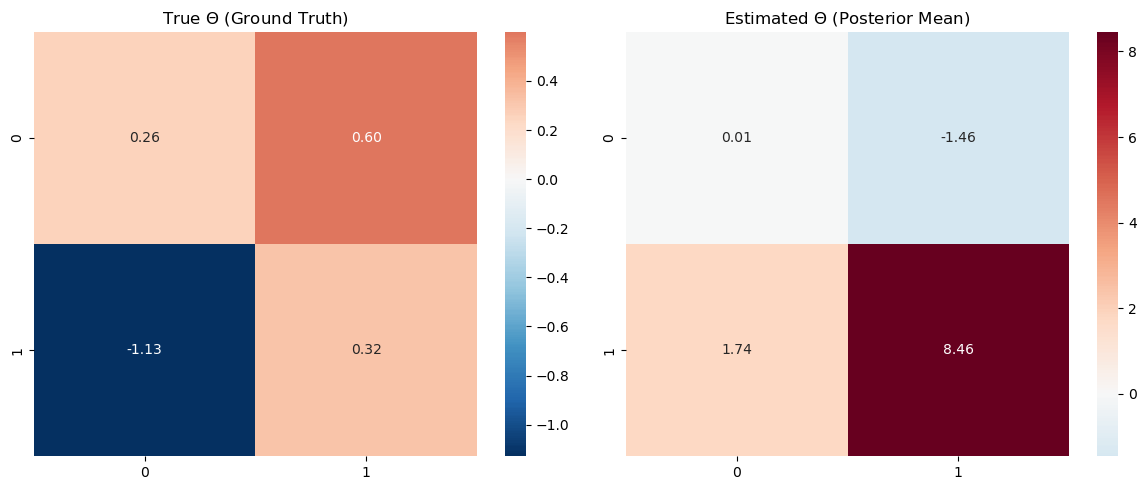

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_theta_comparison(samples, data):
    true_theta = data['true_params']['theta']
    est_theta = jnp.mean(samples['theta_matrix'], axis=0)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.heatmap(true_theta, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
    axes[0].set_title(r"True $\Theta$ (Ground Truth)")
    
    sns.heatmap(est_theta, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1])
    axes[1].set_title(r"Estimated $\Theta$ (Posterior Mean)")
    
    plt.tight_layout()
    plt.show()

plot_theta_comparison(samples, data)

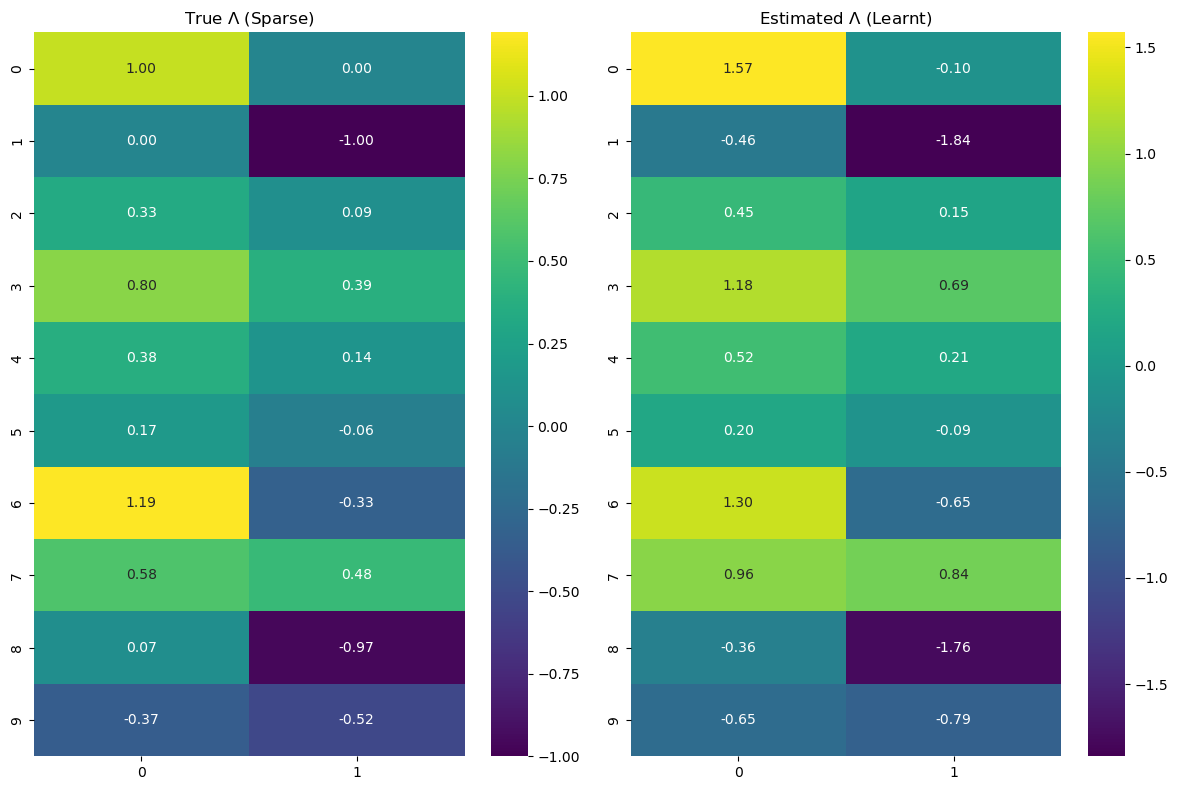

In [24]:
def plot_lambda_comparison(samples, data):
    true_lambda = data['true_params']['Lambda']
    est_lambda = jnp.mean(samples['Lambda'], axis=0)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 8))
    
    sns.heatmap(true_lambda, annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
    axes[0].set_title(r"True $\Lambda$ (Sparse)")
    
    sns.heatmap(est_lambda, annot=True, fmt=".2f", cmap="viridis", ax=axes[1])
    axes[1].set_title(r"Estimated $\Lambda$ (Learnt)")
    
    plt.tight_layout()
    plt.show()

plot_lambda_comparison(samples, data)

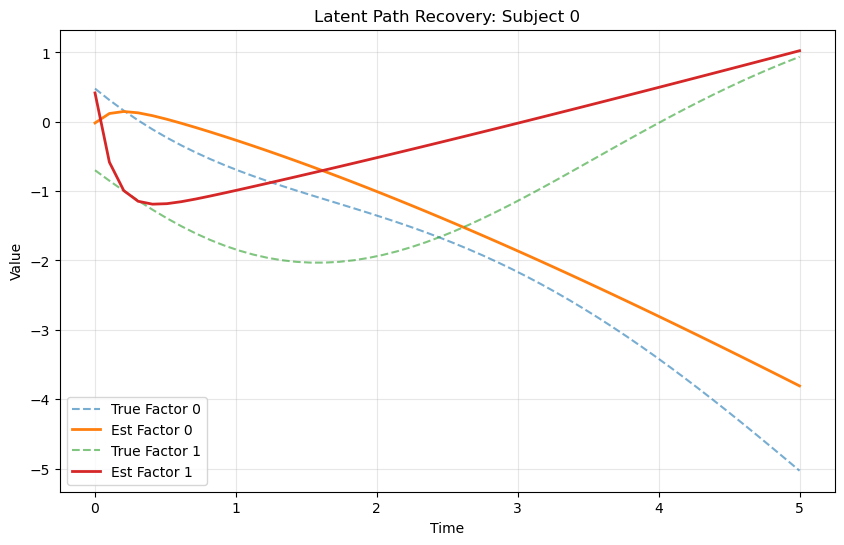

In [25]:
def plot_latent_recovery(samples, data, sub_idx=0):
    true_f = data['f_true'][sub_idx]
    est_f_all = jnp.mean(samples['x_trace'], axis=0)
    
    # Slice the estimated trace for the specific subject
    steps = true_f.shape[0]
    s_idx = data['start_idx'][sub_idx]
    est_f = est_f_all[s_idx : s_idx + steps]
    
    plt.figure(figsize=(10, 6))
    for k in range(true_f.shape[1]):
        plt.plot(data['t'][:steps], true_f[:, k], label=f"True Factor {k}", linestyle="--", alpha=0.6)
        plt.plot(data['t'][:steps], est_f[:, k], label=f"Est Factor {k}", linewidth=2)
    
    plt.title(f"Latent Path Recovery: Subject {sub_idx}")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_latent_recovery(samples, data)

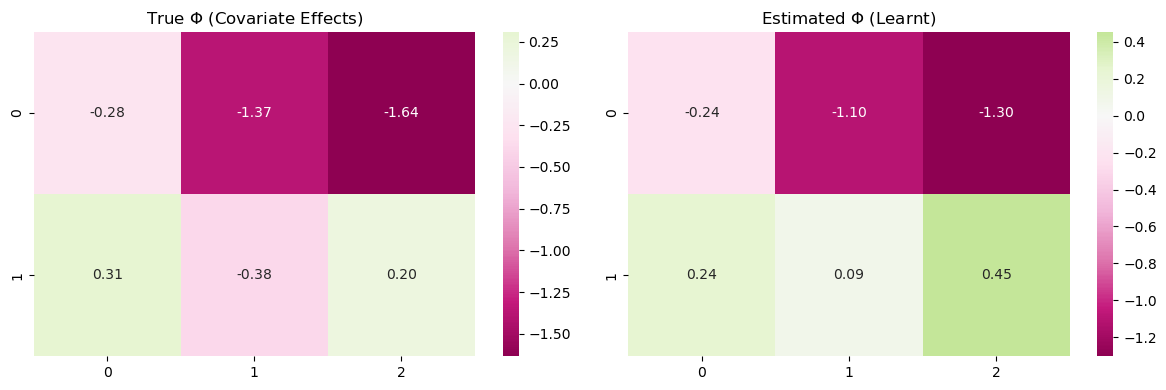

In [26]:
def plot_phi_comparison(samples, data):
    true_phi = data['true_params']['phi']
    est_phi = jnp.mean(samples['phi_latent'], axis=0)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.heatmap(true_phi, annot=True, fmt=".2f", cmap="PiYG", center=0, ax=axes[0])
    axes[0].set_title(r"True $\Phi$ (Covariate Effects)")
    
    sns.heatmap(est_phi, annot=True, fmt=".2f", cmap="PiYG", center=0, ax=axes[1])
    axes[1].set_title(r"Estimated $\Phi$ (Learnt)")
    
    plt.tight_layout()
    plt.show()

plot_phi_comparison(samples, data)

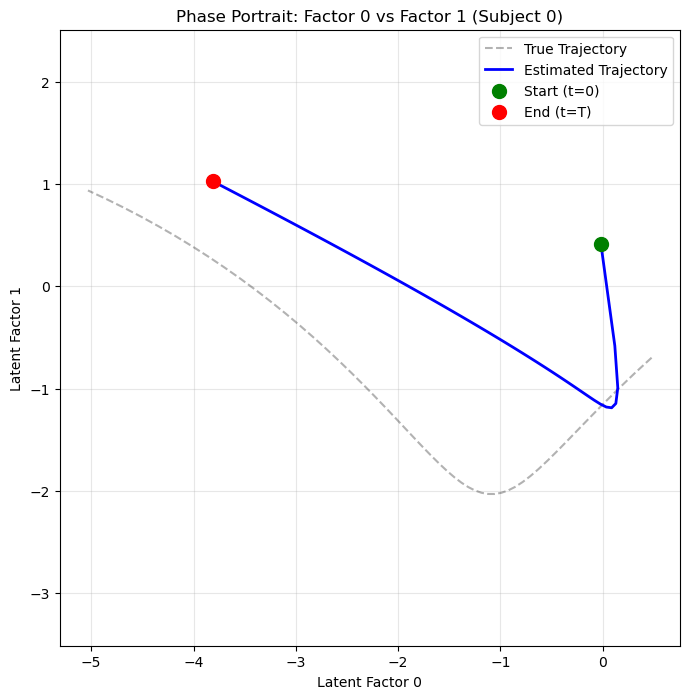

In [27]:
def plot_phase_portrait(samples, data, sub_idx=0):
    true_f = data['f_true'][sub_idx]
    est_f_all = jnp.mean(samples['x_trace'], axis=0)
    
    steps = true_f.shape[0]
    s_idx = data['start_idx'][sub_idx]
    est_f = est_f_all[s_idx : s_idx + steps]
    
    plt.figure(figsize=(8, 8))
    
    # Plot trajectories
    plt.plot(true_f[:, 0], true_f[:, 1], 'k--', alpha=0.3, label="True Trajectory")
    plt.plot(est_f[:, 0], est_f[:, 1], 'b-', linewidth=2, label="Estimated Trajectory")
    
    # Mark start and end points
    plt.scatter(est_f[0, 0], est_f[0, 1], color='green', s=100, label='Start (t=0)', zorder=5)
    plt.scatter(est_f[-1, 0], est_f[-1, 1], color='red', s=100, label='End (t=T)', zorder=5)
    
    plt.title(f"Phase Portrait: Factor 0 vs Factor 1 (Subject {sub_idx})")
    plt.xlabel("Latent Factor 0")
    plt.ylabel("Latent Factor 1")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

plot_phase_portrait(samples, data)

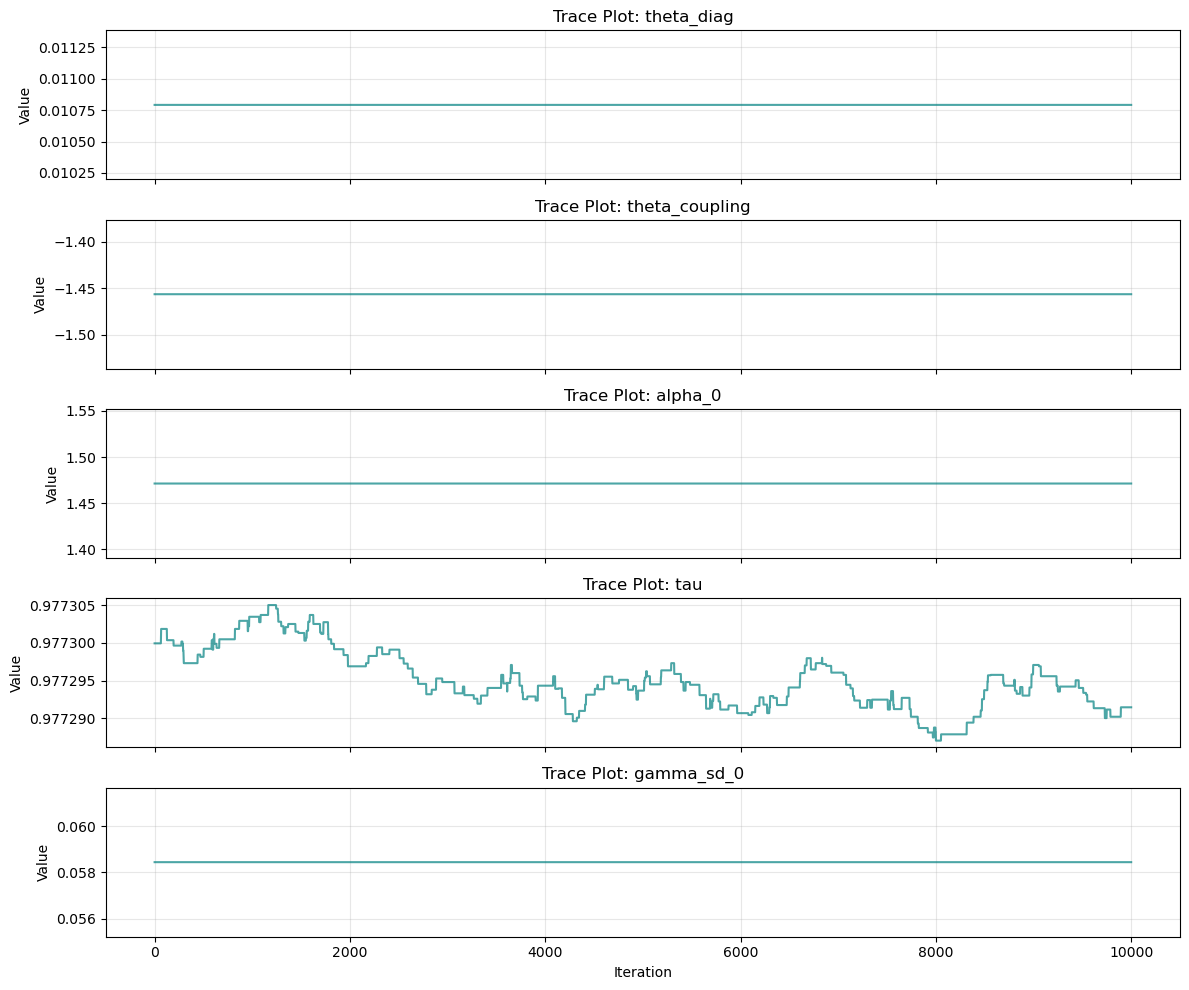

In [28]:
def plot_convergence_traces(samples):
    # Select key parameters to monitor
    # We monitor the matrix entries and global scales
    params_to_plot = {
        "theta_diag": samples['theta_matrix'][:, 0, 0],  # Top-left of Theta
        "theta_coupling": samples['theta_matrix'][:, 0, 1], # Off-diagonal
        "alpha_0": samples['alpha'][:, 0],
        "tau": samples['tau'],
        "gamma_sd_0": samples['gamma_sd'][:, 0]
    }
    
    n_params = len(params_to_plot)
    fig, axes = plt.subplots(n_params, 1, figsize=(12, 2 * n_params), sharex=True)
    
    for i, (name, val) in enumerate(params_to_plot.items()):
        axes[i].plot(val, alpha=0.7, color='teal')
        axes[i].set_ylabel("Value")
        axes[i].set_title(f"Trace Plot: {name}")
        axes[i].grid(True, alpha=0.3)
        
    axes[-1].set_xlabel("Iteration")
    plt.tight_layout()
    plt.show()

plot_convergence_traces(samples)

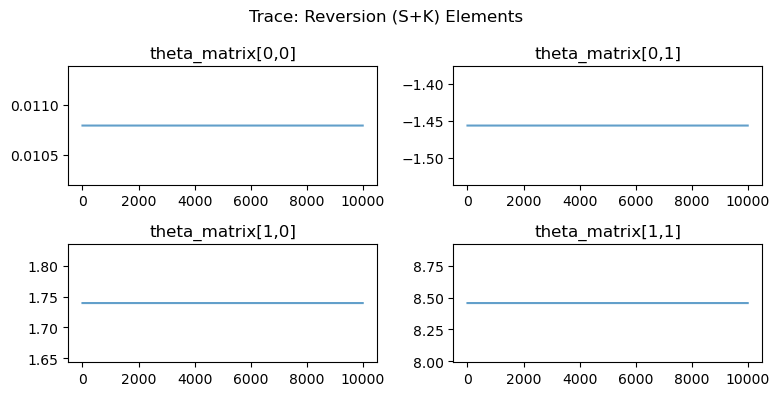

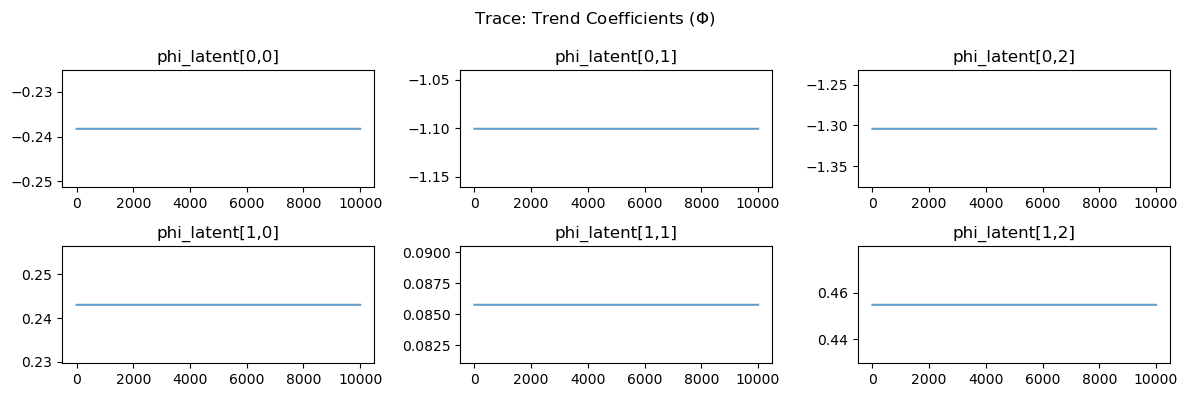

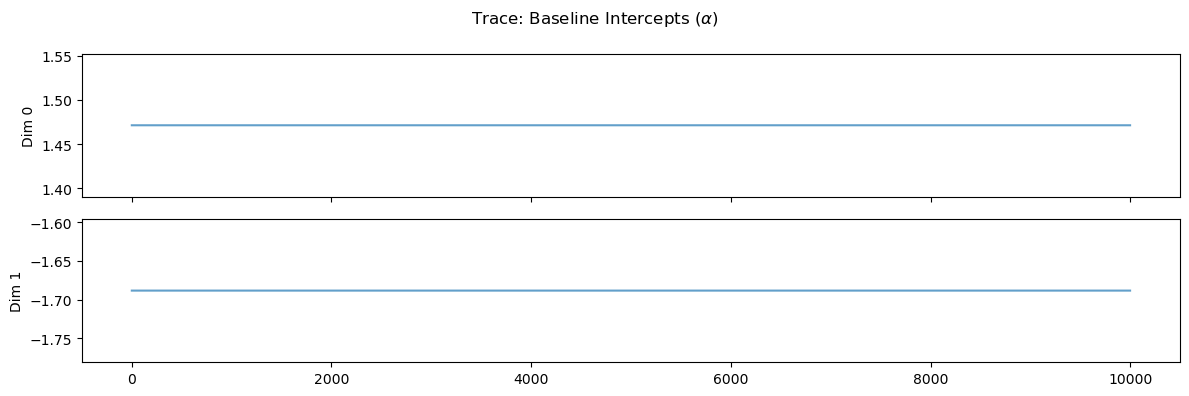

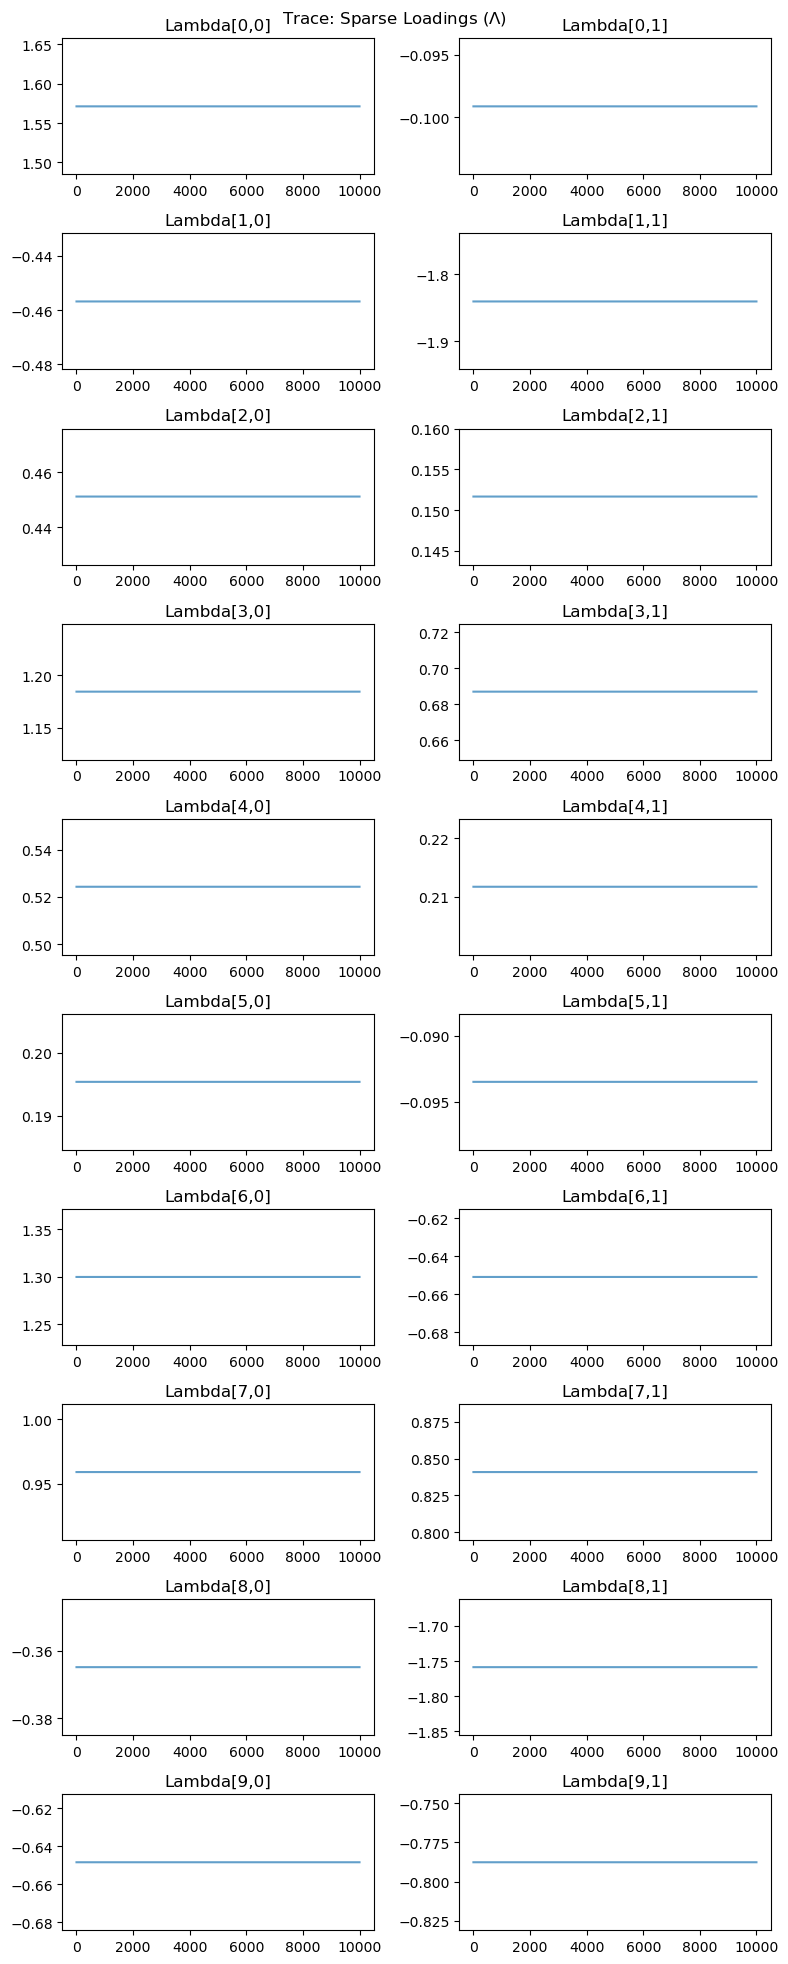

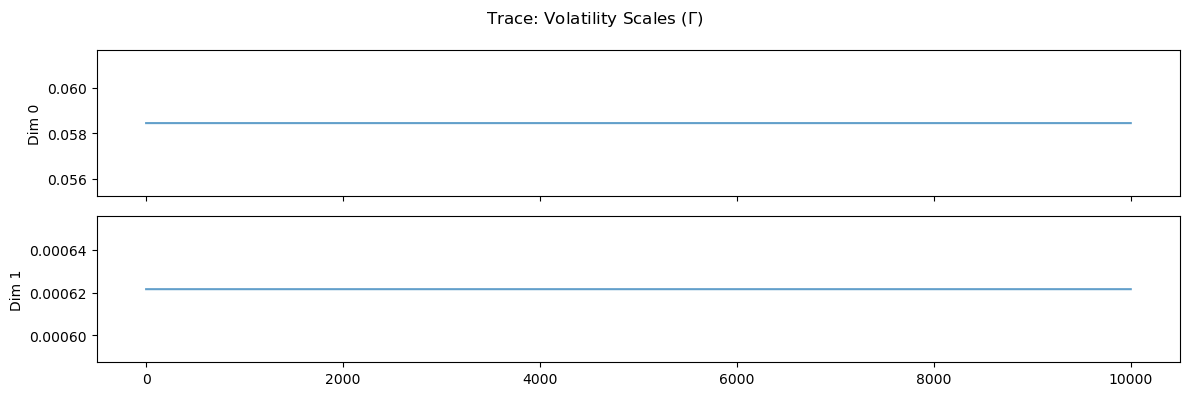

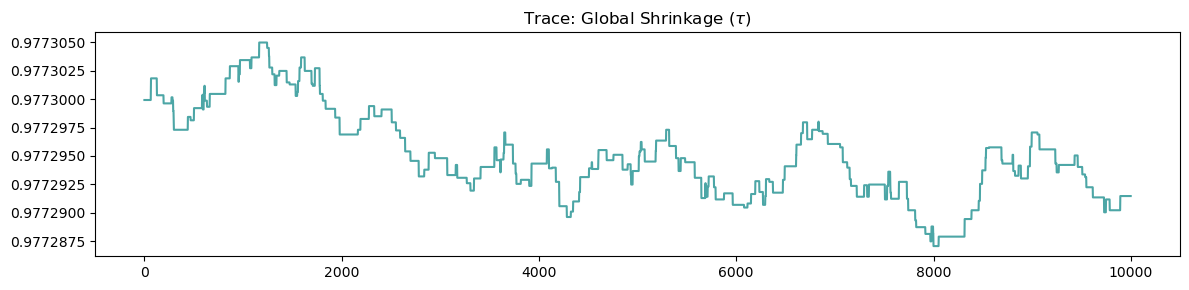

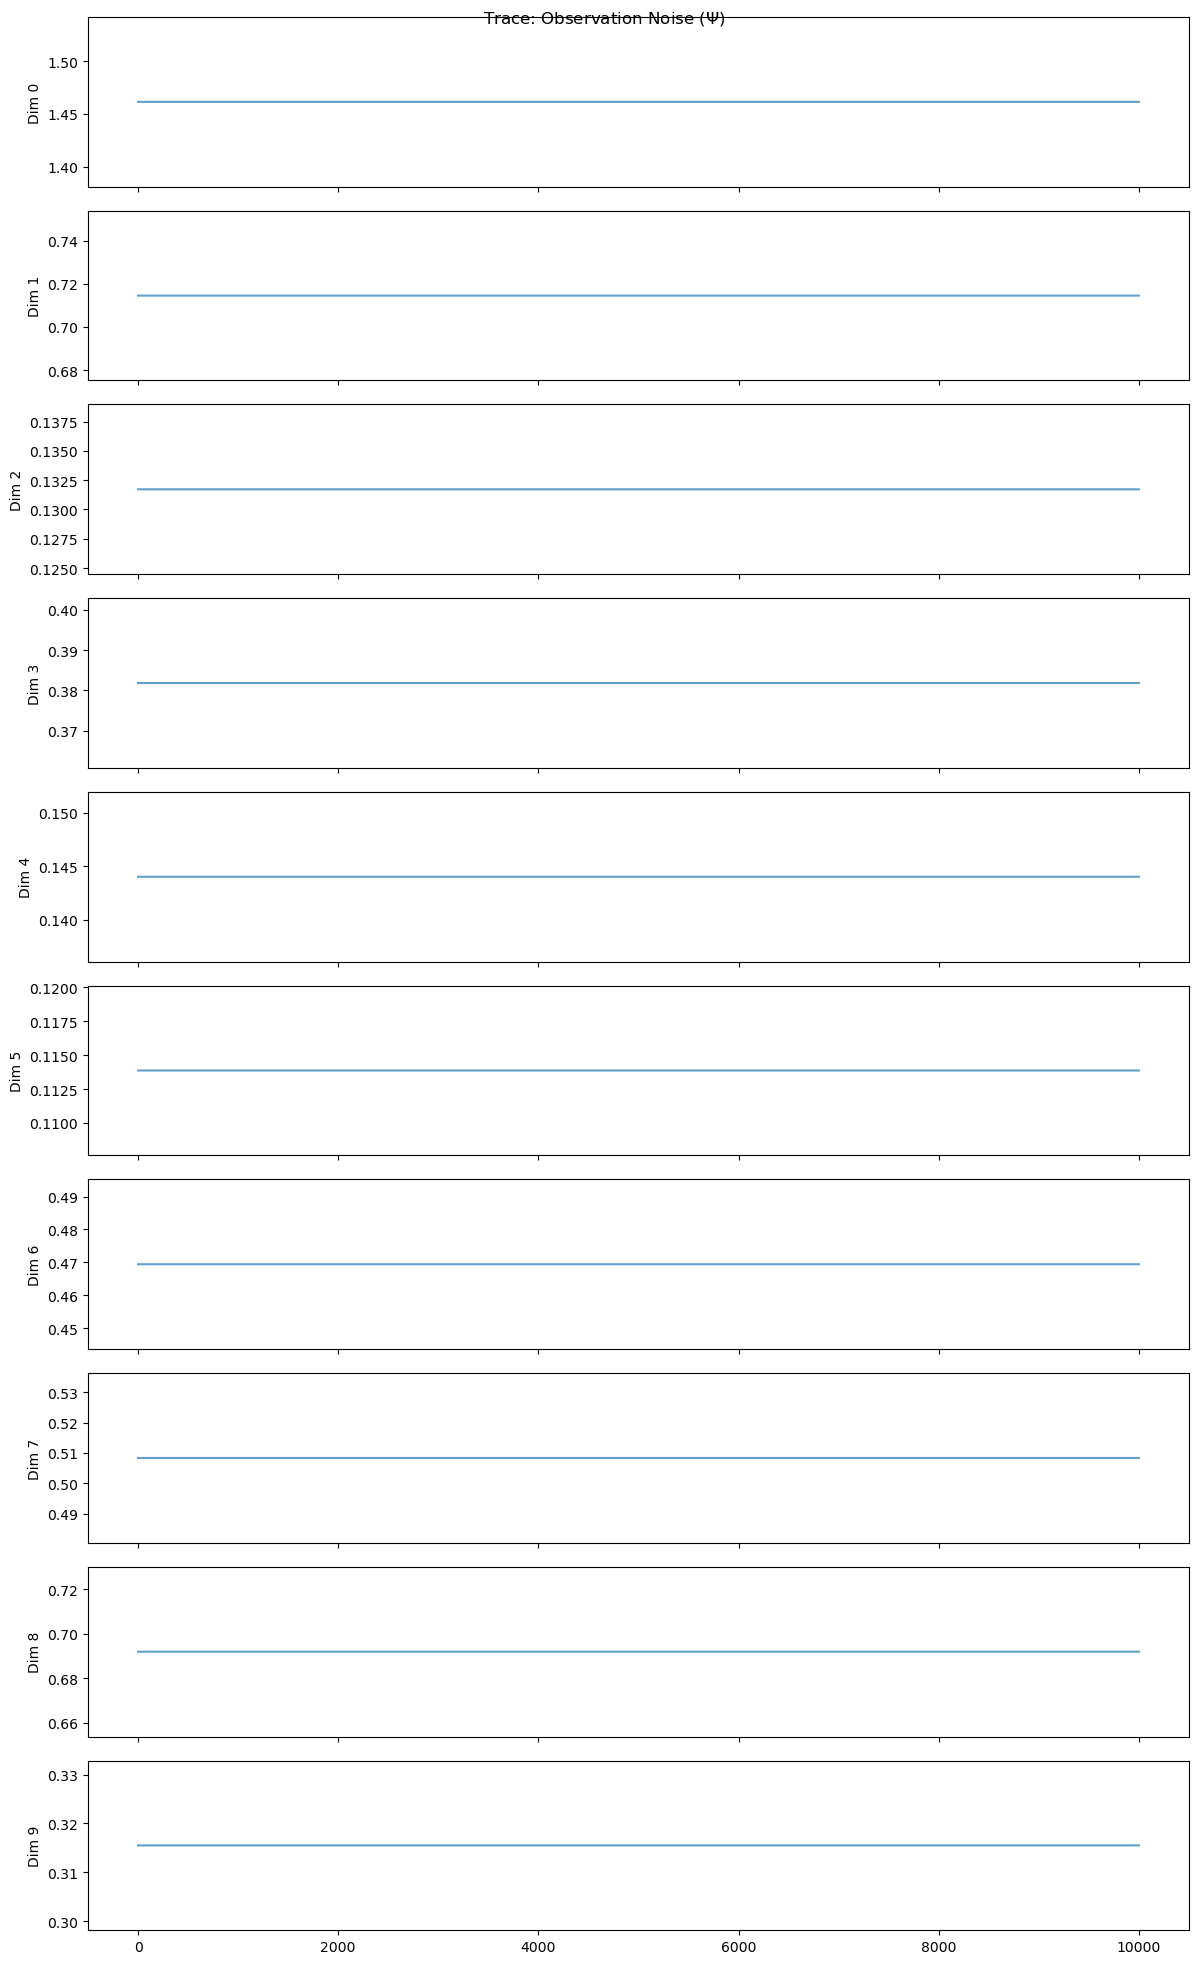

In [29]:
import matplotlib.pyplot as plt

def plot_all_traces(samples):
    """
    Plots MCMC traces for all parameter groups to evaluate convergence.
    """
    # Group parameters for organized plotting
    # We include matrix entries and global hyperparameters
    plot_configs = [
        ("theta_matrix", "Reversion (S+K) Elements"),
        ("phi_latent", r"Trend Coefficients ($\Phi$)"),
        ("alpha", r"Baseline Intercepts ($\alpha$)"),
        ("Lambda", r"Sparse Loadings ($\Lambda$)"),
        ("gamma_sd", r"Volatility Scales ($\Gamma$)"),
        ("tau", r"Global Shrinkage ($\tau$)"),
        ("psi_diag", r"Observation Noise ($\Psi$)")
    ]
    
    for param_key, title in plot_configs:
        data = samples[param_key]
        
        # Handle different dimensions (scalars, vectors, matrices)
        if data.ndim == 1: # Scalar
            fig, ax = plt.subplots(1, 1, figsize=(12, 3))
            ax.plot(data, color='teal', alpha=0.7)
            ax.set_title(f"Trace: {title}")
        elif data.ndim == 2: # Vector (e.g., alpha, gamma_sd)
            n_sub = data.shape[1]
            fig, axes = plt.subplots(n_sub, 1, figsize=(12, 2 * n_sub), sharex=True)
            if n_sub == 1: axes = [axes]
            for j in range(n_sub):
                axes[j].plot(data[:, j], alpha=0.7)
                axes[j].set_ylabel(f"Dim {j}")
            fig.suptitle(f"Trace: {title}")
        elif data.ndim == 3: # Matrix (e.g., theta, Lambda)
            # Plot specific key entries to avoid overcrowding
            rows, cols = data.shape[1], data.shape[2]
            fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 2*rows), squeeze=False)
            for r in range(rows):
                for c in range(cols):
                    axes[r, c].plot(data[:, r, c], alpha=0.7)
                    axes[r, c].set_title(f"{param_key}[{r},{c}]")
            fig.suptitle(f"Trace: {title}")
            
        plt.tight_layout()
        plt.show()

plot_all_traces(samples)